# E-Commerce Business Performance Analytics

This project analyzes e-commerce transactional data
to understand:
- revenue trends,
- customer behavior,
- delivery performance,
- seller performance,
- and customer satisfaction.

Dataset:
Brazilian E-Commerce Public Dataset by Olist.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [ ]:
customers = pd.read_csv('olist_customers_dataset.csv')

orders = pd.read_csv('olist_orders_dataset.csv')

order_items = pd.read_csv('olist_order_items_dataset.csv')

payments = pd.read_csv('olist_order_payments_dataset.csv')

products = pd.read_csv('olist_products_dataset.csv')

reviews = pd.read_csv('olist_order_reviews_dataset.csv')

sellers = pd.read_csv('olist_sellers_dataset.csv')

category_translation = pd.read_csv(
    'product_category_name_translation.csv'
)

In [ ]:
datasets = {
    'customers': customers,
    'orders': orders,
    'order_items': order_items,
    'payments': payments,
    'products': products,
    'reviews': reviews,
    'sellers': sellers
}

overview = []

for name, df in datasets.items():

    data = {

        'Dataset': name,

        'Rows': df.shape[0],

        'Columns': df.shape[1],

        'Missing Values':
        df.isnull().sum().sum(),

        'Duplicate Rows':
        df.duplicated().sum(),

        'Memory Usage (MB)':
        round(
            df.memory_usage(deep=True).sum() / 1024**2,
            2
        )
    }

    overview.append(data)

overview_df = pd.DataFrame(overview)

overview_df

,Dataset,Rows,Columns,Missing Values,Duplicate Rows,Memory Usage (MB)
0,customers,99441,5,0,0,26.59
1,orders,99441,8,4908,0,52.94
2,order_items,112650,7,0,0,35.99
3,payments,103886,5,0,0,16.23
4,products,32951,9,2448,0,6.30
5,reviews,99224,7,145903,0,39.12
6,sellers,3095,4,0,0,0.59


In [ ]:
def column_analysis(df):

    analysis = pd.DataFrame({

        'Data Type':
        df.dtypes,

        'Missing Values':
        df.isnull().sum(),

        'Missing Percentage (%)':
        round(df.isnull().mean() * 100, 2),

        'Unique Values':
        df.nunique(),

        'Duplicate Values':
        df.apply(lambda x: x.duplicated().sum())

    })

    return analysis

In [ ]:
column_analysis(orders)

,Data Type,Missing Values,Missing Percentage (%),Unique Values,Duplicate Values
order_id,object,0,0.00,99441,0
customer_id,object,0,0.00,99441,0
order_status,object,0,0.00,8,99433
order_purchase_timestamp,object,0,0.00,98875,566
order_approved_at,object,160,0.16,90733,8707
order_delivered_carrier_date,object,1783,1.79,81018,18422
order_delivered_customer_date,object,2965,2.98,95664,3776
order_estimated_delivery_date,object,0,0.00,459,98982


<Figure size 1200x600 with 0 Axes>

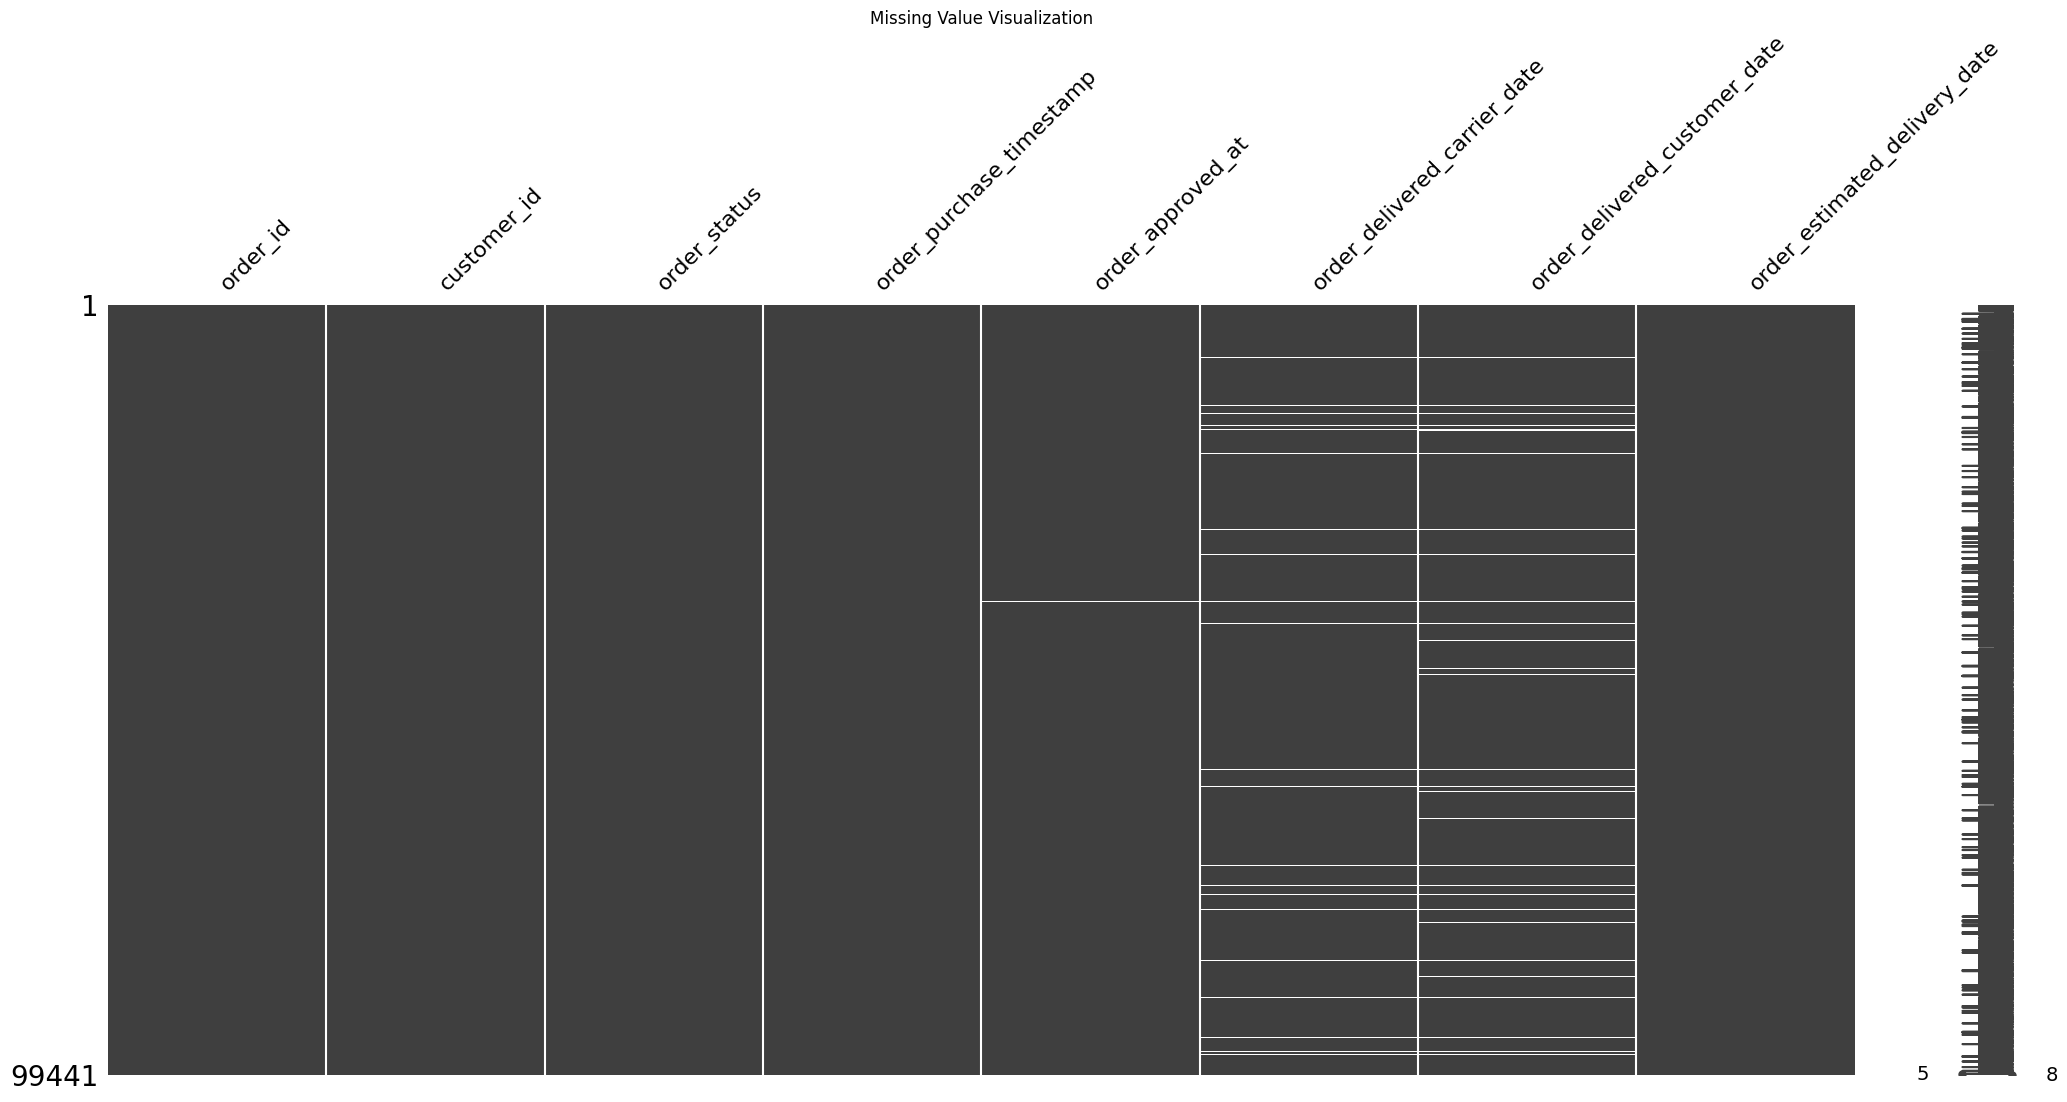

In [ ]:
plt.figure(figsize=(12,6))

msno.matrix(orders)

plt.title(
    'Missing Value Visualization'
)

plt.show()

In [ ]:
date_columns = [

    'order_purchase_timestamp',

    'order_approved_at',

    'order_delivered_carrier_date',

    'order_delivered_customer_date',

    'order_estimated_delivery_date'
]

for col in date_columns:

    orders[col] = pd.to_datetime(
        orders[col]
    )

In [ ]:
orders = orders.dropna(
    subset=['order_delivered_customer_date']
)

In [ ]:
orders = orders.drop_duplicates()

In [ ]:
products = products.merge(

    category_translation,

    on='product_category_name',

    how='left'
)

In [ ]:
df = (

    orders

    .merge(
        customers,
        on='customer_id',
        how='left'
    )

    .merge(
        order_items,
        on='order_id',
        how='left'
    )

    .merge(
        payments,
        on='order_id',
        how='left'
    )

    .merge(
        products,
        on='product_id',
        how='left'
    )

    .merge(
        reviews,
        on='order_id',
        how='left'
    )

    .merge(
        sellers,
        on='seller_id',
        how='left'
    )
)

In [ ]:
df['delivery_days'] = (

    df['order_delivered_customer_date']

    -

    df['order_purchase_timestamp']

).dt.days

In [ ]:
df['late_delivery'] = np.where(

    df['delivery_days']

    >

    (

        df['order_estimated_delivery_date']

        -

        df['order_purchase_timestamp']

    ).dt.days,

    1,

    0
)

In [ ]:
df['purchase_month'] = (

    df['order_purchase_timestamp']

    .dt.to_period('M')
)

In [ ]:
df['revenue'] = (

    df['price']

    +

    df['freight_value']
)

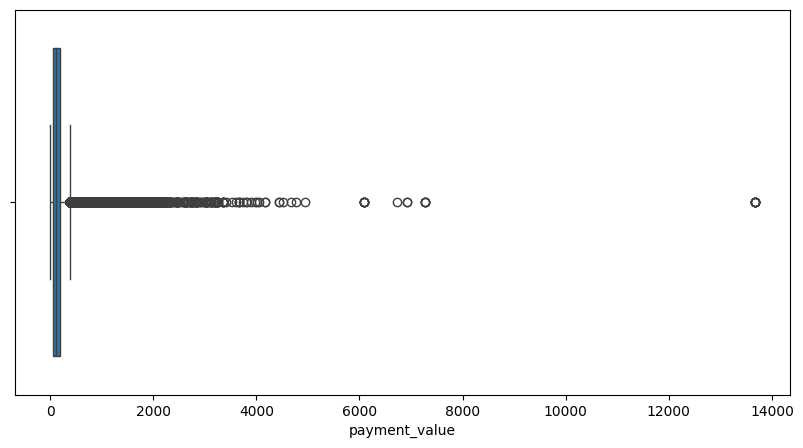

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df['payment_value'])

plt.show()

In [ ]:
Q1 = df['payment_value'].quantile(0.25)

Q3 = df['payment_value'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

In [ ]:
df.to_csv(
    'ecommerce_cleaned.csv',
    index=False
)